In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 80
T2 = 80

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qubit")

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_12090/2557974889.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_12090/2557974889.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_12090/2557974889.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instea

In [4]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [5]:
# build circuit 
# delay gate for ideal setup 
states = []
fids = []
# new_fid = []
duration_cnot = .1
delay_state = trotter.apply(rho_encoded, duration= duration_cnot, unitary=[cnot3, cnot5])
for i in range(len(delay_state)):
    a = qt.ptrace(delay_state[i], [0,1,2])
    states.append(delay_state[i])
    # fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, a))
    # new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=a))
delay_state = trotter.apply(rho=delay_state[-1], duration=duration_cnot, unitary=[cnot4, cnot6])
for i in range(len(delay_state)):
    a = qt.ptrace(delay_state[i], [0,1,2])
    states.append(delay_state[i])


In [6]:
qt.ptrace(states[-1], [0,1,2])[7,7]

(0.9985011281626129+0j)

In [7]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .001
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=[recovery_ops[i]])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

total_time = 2 * duration_cnot + duration_recovery

[0.998687402461383, 0.0005943036435981072, 0.0005918057404011468, 0.0001264881546178075]


In [8]:
qt.ptrace(states[-1], [0,1,2])[7,7]

(0.9986835872445388+0j)

[1.2838247196389454e-07, 0.0002484296329116557, 1.5706974291142824e-07, 0.0005953607895613475, 1.7083900951870208e-07, 0.0001275614468849867, 0.0003446045948788189, 0.9986835872445388]


Text(0.5, 0, 'time (dt)')

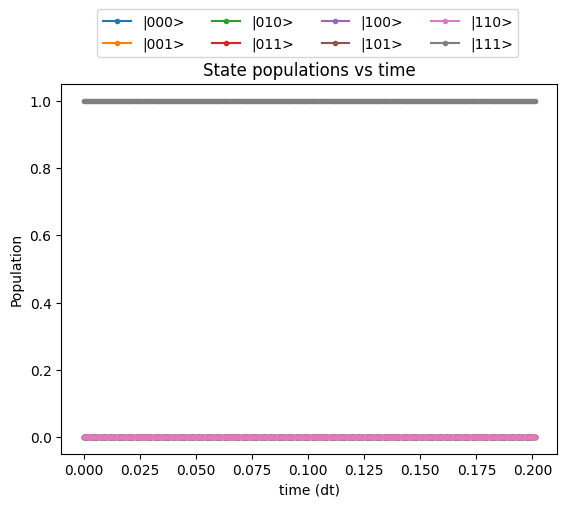

In [9]:
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")

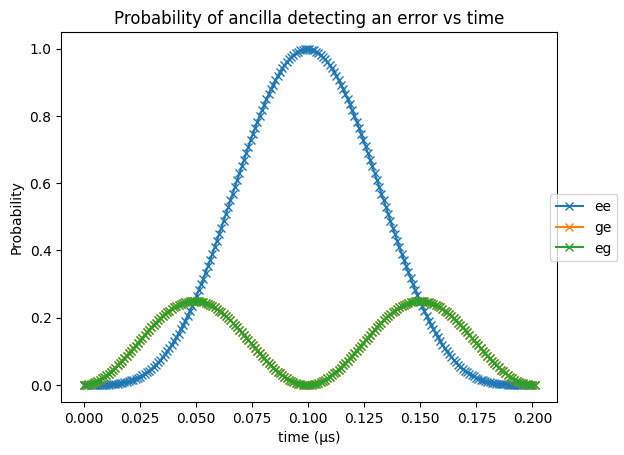

In [10]:
# plotting the ancilla populations 
# getting the probability that the ancillas measure a syndrome 
# states is the function that holds the states as a function o
prob_gg = []
prob_ge = []
prob_eg = []
prob_ee = []

state_gg = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 0)).dag()
state_ge = qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 0), qt.basis(dim, 1)).dag()
state_eg = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 0)).dag()
state_ee = qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)) * qt.tensor(qt.basis(dim, 1), qt.basis(dim, 1)).dag()
for i in states:
    reduced_state = qt.ptrace(i, [3, 4])
    prob_gg.append((state_gg * reduced_state).tr())
    prob_ge.append((state_ge * reduced_state).tr())
    prob_eg.append((state_eg * reduced_state).tr())
    prob_ee.append((state_ee * reduced_state).tr())

probs = [prob_gg, prob_ge, prob_eg, prob_ee]

fig, ax = plt.subplots()
# for i in probs:
#     ax.plot(time, i)
# ax.plot(time, prob_ge)
# ax.plot(time, prob_eg)
ax.plot(time, prob_ee, marker = "x", label = "ee")
ax.plot(time, prob_ge, marker = "x", label = "ge")
ax.plot(time, prob_eg, marker = "x", label = "eg")
    
# seems reasonable 
ax.set_xlabel(u"time (\u03bcs)")
ax.set_ylabel("Probability")
ax.set_title("Probability of ancilla detecting an error vs time")
fig.legend(loc = "center right")

In [11]:
# building circuit based on multiple iterations of the stabilizer 
def stabilizer(rho):
    states = []
    # fids = []
    # new_fid = []
    duration_delay = .1
    delay_state = trotter.apply(rho, duration= duration_delay, unitary=[cnot3, cnot4])
    for i in range(len(delay_state)):
        a = qt.ptrace(delay_state[i], [0,1,2])
        states.append(delay_state[i])
        # fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, a))
        # new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=a))
    delay_state = trotter.apply(rho=delay_state[-1], duration=duration_delay, unitary=[cnot5, cnot6])
    for i in range(len(delay_state)):
        a = qt.ptrace(delay_state[i], [0,1,2])
        states.append(delay_state[i])

    # recovery operation
    # measurement and recovery process 
    # projective measurement 
    proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

    # measurement outcome value 
    outcomes = [(proj * states[-1]).tr() for proj in proj]

    print(outcomes) # check that b,c,d and the same 
    # the list of all of these can be made much cleaner and you should clean it up 

    density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

    # correction_operators
    r00 = qt.tensor([qt.qeye(dim)] * 5)
    r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
    r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
    r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
    recovery_ops = [r00, r01, r10, r11]

    # recovery process but instant 
    duration_recovery = .001
    recovery_states = []
    for i in range(len(recovery_ops)):
        recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=[recovery_ops[i]])
        recovery_states.append(recovery)

    for i in range(int(len(recovery))):
        current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
        states.append(sum(current_state)/(sum(current_state)).tr())
        # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

    total_time = 2 * duration_cnot + duration_recovery

    return states, total_time

In [12]:
qt.ptrace(rho_encoded, [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [13]:
# multiple iterations of the stabilizer 
iterations = 10
states = []
total_time = 0
for i in tqdm(range(iterations)):
    a, b = stabilizer(rho=rho_encoded)
    states.extend(a)
    total_time = total_time + b
    rho_encoded = states[-1]

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:01<00:13,  1.48s/it]

[0.9989058398573675, 0.0007337315734703424, 0.000234126963580145, 0.000126301605582042]


 20%|██        | 2/10 [00:02<00:11,  1.42s/it]

[0.9974017822881385, 0.0012344430866075909, 0.0007356276278712667, 0.0006281469973829052]


...

[0.9900584555616331, 0.004150838345801993, 0.003655391001751041, 0.0021353150908140052]


 90%|█████████ | 9/10 [00:12<00:01,  1.40s/it]

[0.9889746015608913, 0.004381150411903129, 0.004381486439893355, 0.0022627615873123588]


100%|██████████| 10/10 [00:13<00:00,  1.40s/it]

[0.9878959819113817, 0.005104647197422563, 0.004610202765252193, 0.0023891681259436536]


[1.205130719274838e-05, 0.00026059122400722673, 0.0005077191022509586, 0.004598696448879254, 0.0005066829206794261, 0.0018822978353993415, 0.004349785483659817, 0.9878821756779311]


Text(0.5, 0, 'time (dt)')

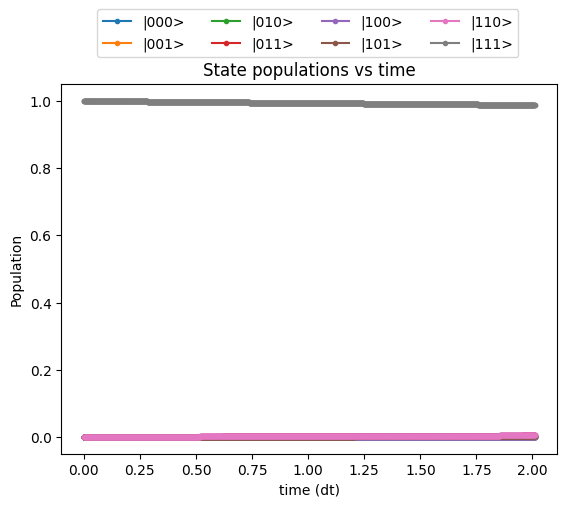

In [14]:
# graphing the results of multiple iterations of the stabilizer with parallel CNOTs 
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")

In [15]:
total_time

2.0100000000000002